# Bassam Kasar India Unemployment Analysis COVID 19 Impact Project

# 1. Let's first import the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load and Inspect the Data

In [2]:
df = pd.read_csv('Unemployment in India.csv')
print("\nShape:", df.shape)
print("\nHead:\n", df.head())
print("\nInfo:")
df.info()


Shape: (768, 7)

Head:
            Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entrie

# 3. Data Cleaning

In [3]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop missing values
df = df.dropna()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

# Sort by date
df = df.sort_values(by='Date')

# 4. Exploratory Data Analysis (EDA)

In [4]:
# Statistical summary
print(df.describe())

# Average unemployment rate by Region
region_stats = (df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index())
print(region_stats)

                             Date  Estimated Unemployment Rate (%)  \
count                         740                       740.000000   
mean   2019-12-12 18:36:58.378378                        11.787946   
min           2019-05-31 00:00:00                         0.000000   
25%           2019-08-31 00:00:00                         4.657500   
50%           2019-11-30 00:00:00                         8.350000   
75%           2020-03-31 00:00:00                        15.887500   
max           2020-06-30 00:00:00                        76.740000   
std                           NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500  
50%          4.744178e+0

# 5. Data Visualization

# A. Unemployment Trend Over Time

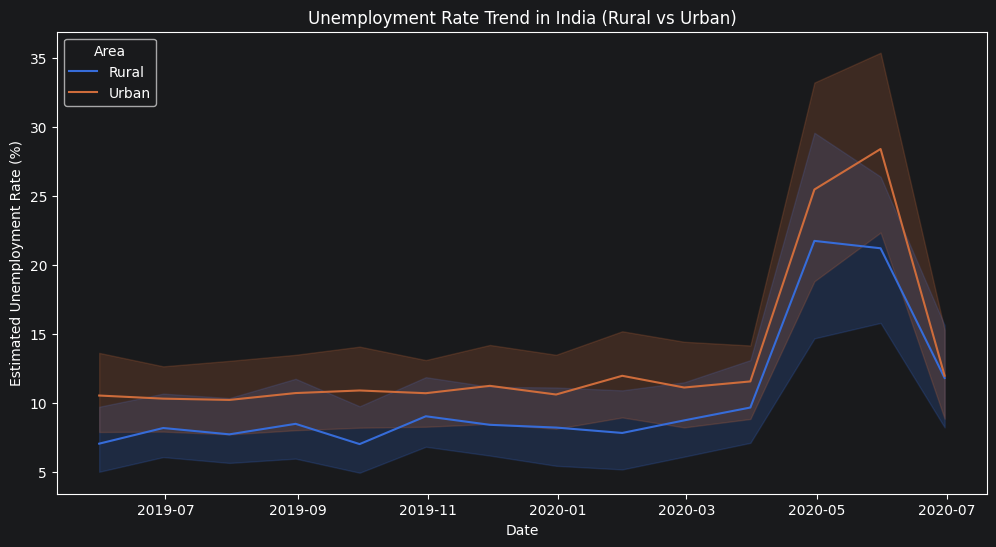

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area')
plt.title('Unemployment Rate Trend in India (Rural vs Urban)')
plt.show()

# B. Regional Comparison

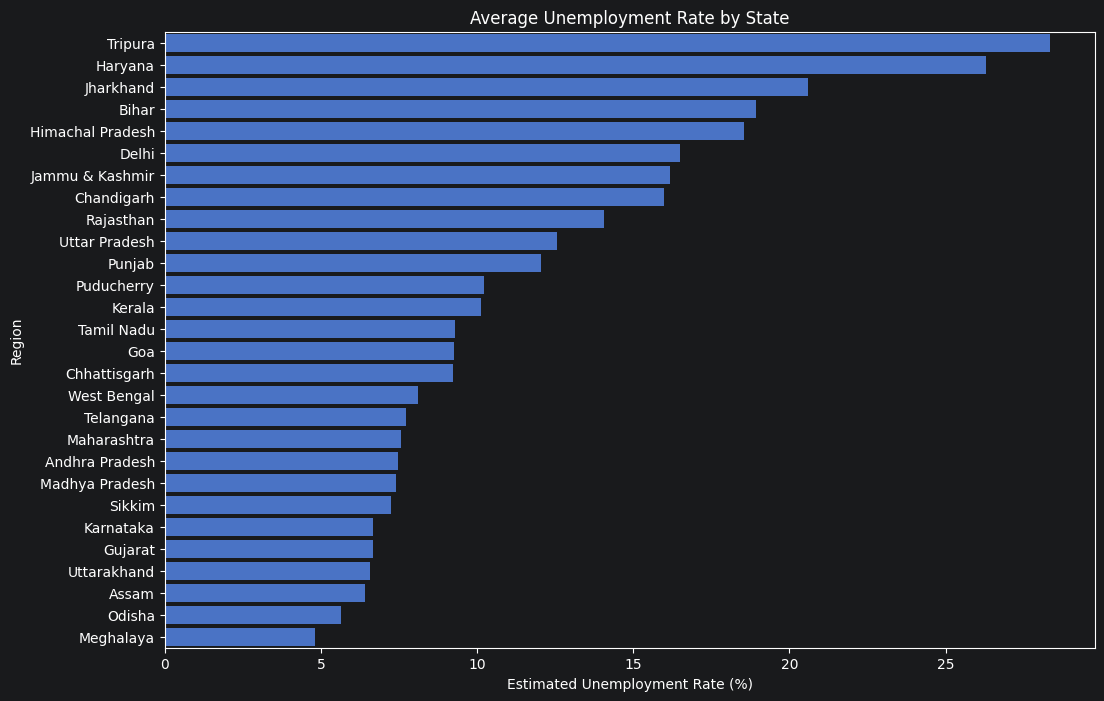

In [6]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=region_stats, errorbar=None)
plt.title('Average Unemployment Rate by State')
plt.show()